In [ ]:
# menghubungkan colab dengan google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# memanggil data set lewat gdrive
path = "/content/drive/MyDrive/Machine_Learning/praktikum6/data"

In [ ]:
# import library
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report,accuracy_score

In [ ]:
#Membaca data csv
import pandas as pd
df = pd.read_csv(path + "/data_bank.csv", header=None)
df.columns = ['variance', 'skewness', 'curtosis', 'entropy','class']
df.head()


,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [ ]:
# Melihat informasi
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


In [ ]:
# Menampilkan statistika deskriptif dari dataset
df.describe()

,variance,skewness,curtosis,entropy,class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [ ]:
# Cek nilai
df["class"].unique()



array([0, 1])

In [ ]:
# menghitung jumlah kolom spesies

df["class"].value_counts()

,count
class,
0,762
1,610


In [ ]:
# pemilihan fitur dan model
X = df.drop('class', axis=1)
y = df['class']

# kolom target
y = df['class']

X.head()


,variance,skewness,curtosis,entropy
0,3.62160,8.6661,-2.8073,-0.44699
1,4.54590,8.1674,-2.4586,-1.46210
2,3.86600,-2.6383,1.9242,0.10645
3,3.45660,9.5228,-4.0112,-3.59440
4,0.32924,-4.4552,4.5718,-0.98880


In [ ]:
y.head()

,class
0,0
1,0
2,0
3,0
4,0


In [ ]:
# split data dan membuat model SVM
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = SVC(kernel='linear')
model.fit(X_train,y_train)

SVC(kernel='linear')

In [ ]:
# Evaluasi
y_pred = model.predict(X_test)

# Menghitung akurasi
print(f"Akurasi: {accuracy_score(y_test, y_pred) * 100:.2f}%")

# Laporan klasifikasi
print("\nLaporan Klasifikasi:\n", classification_report(y_test, y_pred))



Akurasi: 98.55%

Laporan Klasifikasi:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       148
           1       0.98      0.98      0.98       127

    accuracy                           0.99       275
   macro avg       0.99      0.99      0.99       275
weighted avg       0.99      0.99      0.99       275




Confusion Matrix:
 [[146   2]
 [  2 125]]


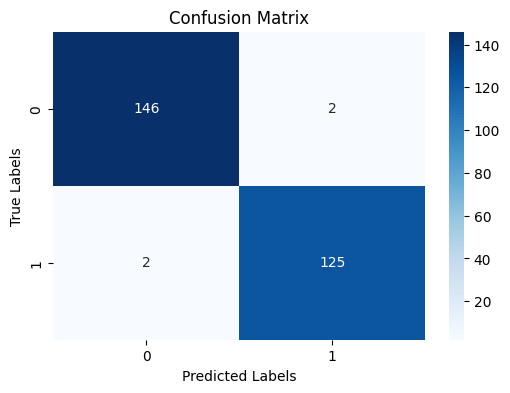

In [ ]:
# Confusion matrix

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Menampilkan confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.show()

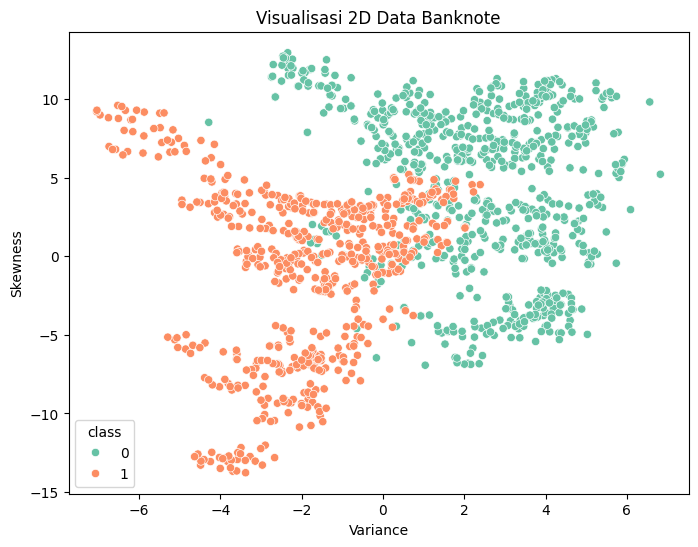

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=df['variance'], y=df['skewness'], hue=df['class'], palette='Set2')
plt.title('Visualisasi 2D Data Banknote')
plt.xlabel('Variance')
plt.ylabel('Skewness')
plt.show()

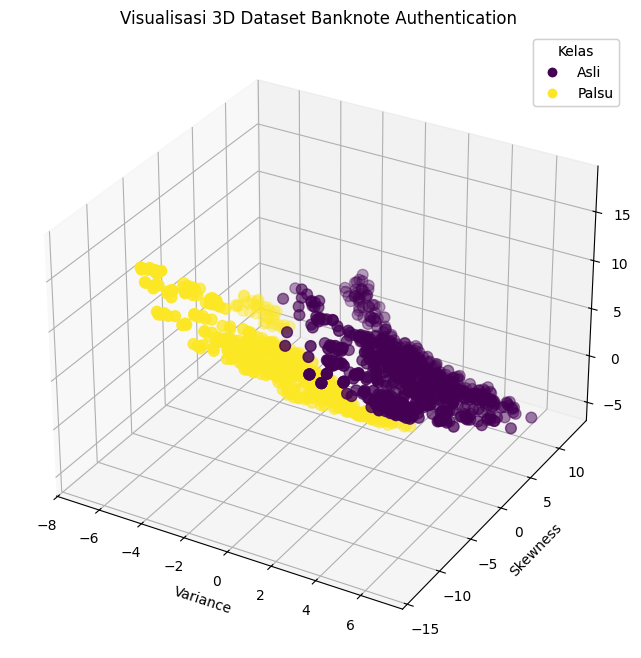

In [ ]:
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['class_encoded'] = le.fit_transform(df['class'])

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

x = df['variance']
y = df['skewness']
z = df['curtosis']

scatter = ax.scatter(x, y, z, c=df['class_encoded'], cmap='viridis', s=60)
ax.set_title('Visualisasi 3D Dataset Banknote Authentication')
ax.set_xlabel('Variance')
ax.set_ylabel('Skewness')
ax.set_zlabel('Curtosis')

legend_labels = ['Asli', 'Palsu']
legend = ax.legend(handles=scatter.legend_elements()[0], labels=legend_labels, title="Kelas")
ax.add_artist(legend)

plt.show()
